# Figuras del póster — JIC 2026

**Predicción de toxicidad de agroquímicos con GNN-GIN + XAI**

Este notebook genera las cuatro figuras del póster a partir de los resultados **reales** del proyecto (no del contenido erróneo de PFH/FPFH). Cada figura se guarda en `outputs/poster/` en PNG a 200 dpi.

| Figura | Sección del póster | Fuente de datos |
|---|---|---|
| `fig1_comparacion_modelos.png` | RESULTADOS (modelo vs otros) | `baseline_results.csv`, `gin_cv_summary.csv` |
| `fig2_auc_por_tarea.png` | MÉTRICAS DE COMPARACIÓN OBTENIDAS | `gin_results.csv` |
| `fig3_aplicacion_panama.png` | RESULTADOS (corpus panameño) | `panama_predictions.csv` |
| `fig4_folds_cv.png` | Validación cruzada (5-fold) | `gin_cv_summary.csv` |

## 1. Configuración y paleta

Usamos **DejaVu Sans** (fuente por defecto de matplotlib) que soporta acentos y ñ correctamente.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Rutas relativas a la raíz del repositorio
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RESULTS = ROOT / 'outputs' / 'results'
OUT = ROOT / 'outputs' / 'poster'
OUT.mkdir(parents=True, exist_ok=True)

# Paleta coherente con el póster
PURPLE = '#2E2A6E'
CORAL  = '#E8654F'
GREEN  = '#3FA776'
GREY   = '#B9B9C6'
GOLD   = '#E9A23B'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',   # soporta acentos y ñ
    'font.size': 13,
    'axes.edgecolor': '#555',
    'axes.linewidth': 0.9,
    'figure.dpi': 120,              # 120 en pantalla; se guarda a 200
    'savefig.dpi': 200,
    'axes.unicode_minus': False,
})

TASKS = ['NR-AR','NR-AR-LBD','NR-AhR','NR-Aromatase','NR-ER','NR-ER-LBD',
         'NR-PPAR-gamma','SR-ARE','SR-AtAD5','SR-HSE','SR-MMP','SR-p53']
print('Salida:', OUT)

Salida: C:\Users\mateo\Desktop\PROYECTOS\JIC2026\outputs\poster


## 2. Carga de datos

In [2]:
base = pd.read_csv(RESULTS / 'baseline_results.csv')
cv   = pd.read_csv(RESULTS / 'gin_cv_summary.csv')
gin  = pd.read_csv(RESULTS / 'gin_results.csv').iloc[0]
pan  = pd.read_csv(RESULTS / 'panama_predictions.csv')

rf  = float(base.loc[base.Modelo == 'Random Forest', 'Media AUC-ROC'].iloc[0])
mlp = float(base.loc[base.Modelo == 'MLP', 'Media AUC-ROC'].iloc[0])
s2v = float(base.loc[base.Modelo == 'SMILES2vec', 'Media AUC-ROC'].iloc[0])
gin_mean = cv['mean_auc'].mean()
gin_std  = cv['mean_auc'].std(ddof=1)

print(f'GNN-GIN  = {gin_mean:.3f} ± {gin_std:.3f}')
print(f'RF={rf:.3f}  MLP={mlp:.3f}  SMILES2vec={s2v:.3f}')
print(f'Corpus panameño: n={len(pan)}')

GNN-GIN  = 0.785 ± 0.023
RF=0.743  MLP=0.707  SMILES2vec=0.727
Corpus panameño: n=235


## 3. Figura 1 — Comparación de modelos (sección RESULTADOS)

Media de AUC-ROC de la GNN-GIN frente a los tres baselines, bajo el mismo protocolo (scaffold split + 5-fold CV).

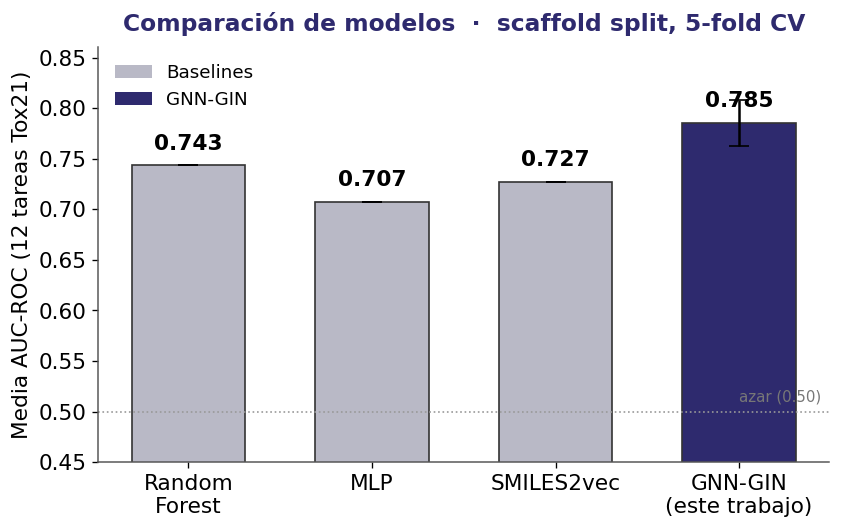

In [3]:
models = ['Random\nForest', 'MLP', 'SMILES2vec', 'GNN-GIN\n(este trabajo)']
vals   = [rf, mlp, s2v, gin_mean]
errs   = [0, 0, 0, gin_std]
colors = [GREY, GREY, GREY, PURPLE]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(models, vals, yerr=errs, capsize=6, color=colors, edgecolor='#333', width=0.62)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.3f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.axhline(0.5, color='#999', ls=':', lw=1)
ax.text(3.45, 0.51, 'azar (0.50)', color='#777', fontsize=9, ha='right')
ax.set_ylim(0.45, 0.86)
ax.set_ylabel('Media AUC-ROC (12 tareas Tox21)')
ax.set_title('Comparación de modelos  ·  scaffold split, 5-fold CV',
             fontweight='bold', color=PURPLE, fontsize=14, pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[Patch(facecolor=GREY, label='Baselines'),
                   Patch(facecolor=PURPLE, label='GNN-GIN')],
          loc='upper left', frameon=False, fontsize=11)
plt.tight_layout()
plt.savefig(OUT / 'fig1_comparacion_modelos.png', bbox_inches='tight')
plt.show()

## 4. Figura 2 — AUC-ROC por diana Tox21 (sección MÉTRICAS DE COMPARACIÓN)

Precisión del modelo (AUC-ROC en test) para cada una de las 12 dianas biológicas.

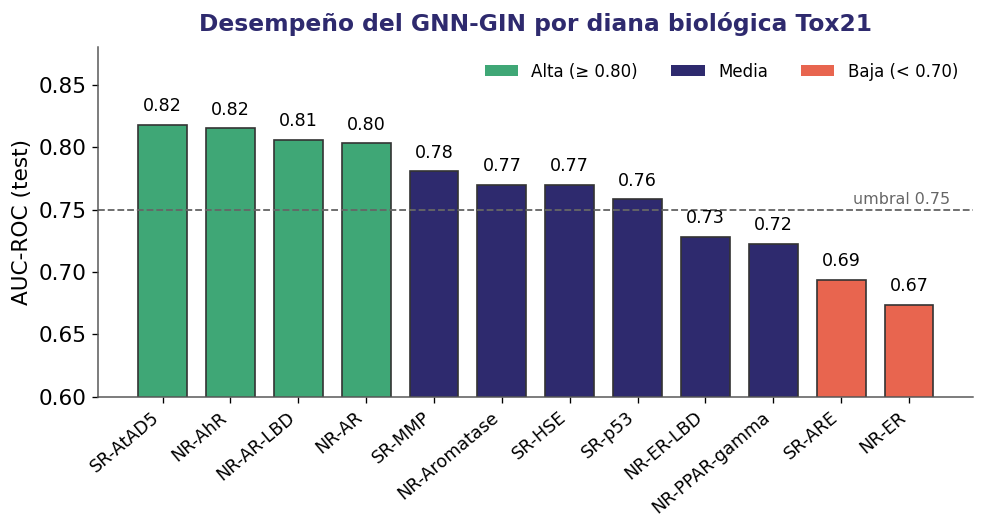

In [4]:
per_task = np.array([gin[t] for t in TASKS], dtype=float)
order = np.argsort(per_task)[::-1]
tsorted = [TASKS[i] for i in order]
vsorted = per_task[order]
bar_colors = [GREEN if v >= 0.80 else (CORAL if v < 0.70 else PURPLE) for v in vsorted]

fig, ax = plt.subplots(figsize=(8.4, 4.6))
ax.bar(range(len(tsorted)), vsorted, color=bar_colors, edgecolor='#333', width=0.72)
for i, v in enumerate(vsorted):
    ax.text(i, v + 0.008, f'{v:.2f}', ha='center', va='bottom', fontsize=10.5)
ax.axhline(0.75, color='#666', ls='--', lw=1.1)
ax.text(len(tsorted) - 0.4, 0.755, 'umbral 0.75', color='#666', fontsize=9.5, ha='right')
ax.set_xticks(range(len(tsorted)))
ax.set_xticklabels(tsorted, rotation=40, ha='right', fontsize=10.5)
ax.set_ylim(0.60, 0.88)
ax.set_ylabel('AUC-ROC (test)')
ax.set_title('Desempeño del GNN-GIN por diana biológica Tox21',
             fontweight='bold', color=PURPLE, fontsize=14, pad=10)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=[Patch(facecolor=GREEN, label='Alta (≥ 0.80)'),
                   Patch(facecolor=PURPLE, label='Media'),
                   Patch(facecolor=CORAL, label='Baja (< 0.70)')],
          loc='upper right', frameon=False, fontsize=10, ncol=3)
plt.tight_layout()
plt.savefig(OUT / 'fig2_auc_por_tarea.png', bbox_inches='tight')
plt.show()

## 5. Figura 3 — Aplicación al corpus panameño (sección RESULTADOS)

(a) Distribución de niveles de riesgo asignados por el modelo. (b) Probabilidad media predicha por vía de toxicidad.

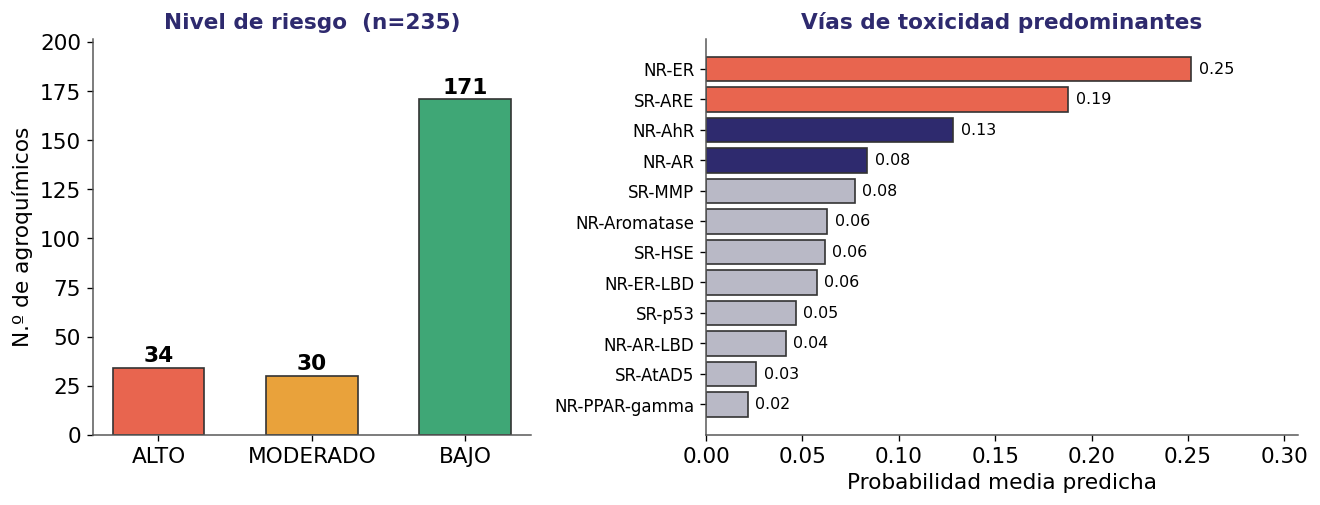

In [5]:
alert_order = ['ALTO', 'MODERADO', 'BAJO']
counts = [(pan['alerta'] == a).sum() for a in alert_order]
acolors = [CORAL, GOLD, GREEN]
mean_prob = pan[TASKS].mean().sort_values(ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.4),
                               gridspec_kw={'width_ratios': [1, 1.35]})

# (a) niveles de riesgo
b = ax1.bar(alert_order, counts, color=acolors, edgecolor='#333', width=0.6)
for bar, c in zip(b, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, c + 3, str(c), ha='center', fontweight='bold')
ax1.set_ylabel('N.º de agroquímicos')
ax1.set_title(f'Nivel de riesgo  (n={len(pan)})', fontweight='bold', color=PURPLE, fontsize=13)
ax1.spines[['top', 'right']].set_visible(False)
ax1.set_ylim(0, max(counts) * 1.18)

# (b) probabilidad media por vía
yc = [CORAL if v >= 0.15 else (PURPLE if v >= 0.08 else GREY) for v in mean_prob.values]
ax2.barh(range(len(mean_prob)), mean_prob.values, color=yc, edgecolor='#333')
ax2.set_yticks(range(len(mean_prob)))
ax2.set_yticklabels(mean_prob.index, fontsize=10)
for i, v in enumerate(mean_prob.values):
    ax2.text(v + 0.004, i, f'{v:.2f}', va='center', fontsize=9.5)
ax2.set_xlabel('Probabilidad media predicha')
ax2.set_title('Vías de toxicidad predominantes', fontweight='bold', color=PURPLE, fontsize=13)
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_xlim(0, mean_prob.max() * 1.22)
plt.tight_layout()
plt.savefig(OUT / 'fig3_aplicacion_panama.png', bbox_inches='tight')
plt.show()

## 6. Figura 4 — Validación cruzada 5-fold (reemplaza la sección de descriptores)

(a) AUC-ROC media por fold con banda media ± desviación estándar. (b) Mapa de calor de AUC-ROC por tarea y fold.

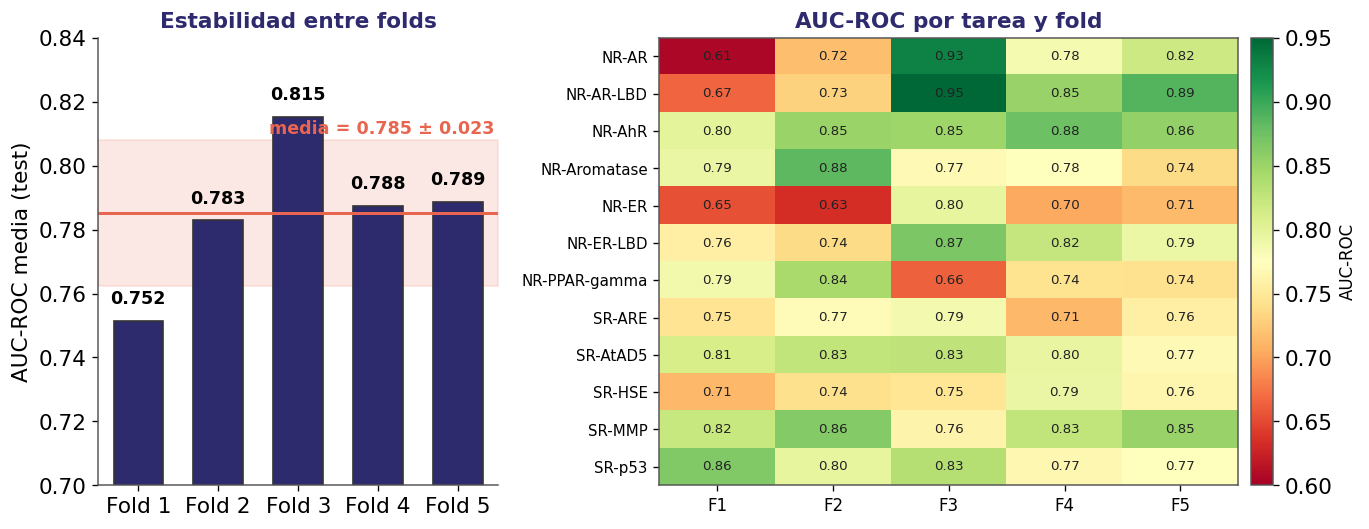

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.6, 4.6),
                               gridspec_kw={'width_ratios': [1, 1.55]})

# (a) AUC por fold
folds = cv['fold'].astype(int).values
fauc  = cv['mean_auc'].values
b = ax1.bar([f'Fold {f}' for f in folds], fauc, color=PURPLE, edgecolor='#333', width=0.62)
for bar, v in zip(b, fauc):
    ax1.text(bar.get_x() + bar.get_width()/2, v + 0.004, f'{v:.3f}',
             ha='center', va='bottom', fontsize=10.5, fontweight='bold')
ax1.axhline(gin_mean, color=CORAL, lw=1.8)
ax1.fill_between([-0.5, len(folds) - 0.5], gin_mean - gin_std, gin_mean + gin_std,
                 color=CORAL, alpha=0.15, zorder=0)
ax1.text(len(folds) - 0.55, gin_mean + gin_std + 0.002,
         f'media = {gin_mean:.3f} ± {gin_std:.3f}', color=CORAL,
         fontsize=10.5, ha='right', fontweight='bold')
ax1.set_xlim(-0.5, len(folds) - 0.5)
ax1.set_ylim(0.70, 0.84)
ax1.set_ylabel('AUC-ROC media (test)')
ax1.set_title('Estabilidad entre folds', fontweight='bold', color=PURPLE, fontsize=13)
ax1.spines[['top', 'right']].set_visible(False)

# (b) heatmap tarea x fold
mat = cv[TASKS].values.T
im = ax2.imshow(mat, aspect='auto', cmap='RdYlGn', vmin=0.60, vmax=0.95)
ax2.set_xticks(range(len(folds)))
ax2.set_xticklabels([f'F{f}' for f in folds], fontsize=10)
ax2.set_yticks(range(len(TASKS)))
ax2.set_yticklabels(TASKS, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax2.text(j, i, f'{mat[i, j]:.2f}', ha='center', va='center', fontsize=8, color='#222')
ax2.set_title('AUC-ROC por tarea y fold', fontweight='bold', color=PURPLE, fontsize=13)
cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.02)
cbar.set_label('AUC-ROC', fontsize=10)
plt.tight_layout()
plt.savefig(OUT / 'fig4_folds_cv.png', bbox_inches='tight')
plt.show()

## 7. Resumen numérico para los textos del póster

In [7]:
print('=== Comparación de modelos (media AUC-ROC) ===')
print(f'  GNN-GIN     : {gin_mean:.3f} ± {gin_std:.3f}')
print(f'  Random Forest: {rf:.3f}')
print(f'  SMILES2vec  : {s2v:.3f}')
print(f'  MLP         : {mlp:.3f}')
print(f'  Ganancia GIN vs mejor baseline: +{gin_mean - rf:.3f}')
print()
print('=== Rango de folds ===')
print(f'  min={fauc.min():.3f}  max={fauc.max():.3f}')
print()
print('=== Corpus panameño ===')
print(pan['alerta'].value_counts().to_string())
print()
print('Tarea crítica más frecuente:')
print(pan['tarea_critica'].value_counts().head(3).to_string())

=== Comparación de modelos (media AUC-ROC) ===
  GNN-GIN     : 0.785 ± 0.023
  Random Forest: 0.743
  SMILES2vec  : 0.727
  MLP         : 0.707
  Ganancia GIN vs mejor baseline: +0.042

=== Rango de folds ===
  min=0.752  max=0.815

=== Corpus panameño ===
alerta
BAJO        171
ALTO         34
MODERADO     30

Tarea crítica más frecuente:
tarea_critica
NR-ER     144
SR-ARE     28
NR-AhR     23
